# Cvičenie 2 - Časové rady
&nbsp;

Časové rady sú dátové množiny pri ktorých sú jednotlivé hodnoty usporiadané sekvenčne
v čase. Sú definované počiatočným a koncovým časom (napr. dáta od roku 2016 do 2017)
a frekvenciou vzorkovania (napr. s frekvenciou 12 pre mesačné dáta). V prostredí R sa
používajú na reprezentáciu časových radov objekty typu `ts`, ktoré môžete priamo načítať ako
dátovú množinu. 


Množina `AirPassengers` udáva nárast cestujúcich v leteckej dobre v USA a obsahuje hodnoty
od `januára 1949 (1949,1)` do `decembra 1960 (1960,12)`. Vzorkovacia frekvencia je `12 hodnôt`
na rok (tzv. mesačné dáta). 

Funkcia `summary(ts)` zobrazuje len základné charakteristiky číselný hodnôt,
ktoré tvoria časový rad. Počiatočný a koncový čas a frekvenciu vzorkovania môžete vypísať
funkciami `start(ts)`, `end(ts)` a `frequency(ts)`:

In [ ]:
data("AirPassengers")
ap = AirPassengers

In [ ]:
summary(ap)

In [ ]:
start(ap)

In [ ]:
end(ap)

In [ ]:
frequency(ap)

In [2]:
data("AirPassengers")
ap = AirPassengers

summary(ap)
start(ap)
end(ap)
frequency(ap)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  104.0   180.0   265.5   280.3   360.5   622.0 

[1] 1949    1

[1] 1960   12

[1] 12

Časové rady si môžete priamo vykresliť pomocou funkcie plot:

In [ ]:
plot(ap, type="o")

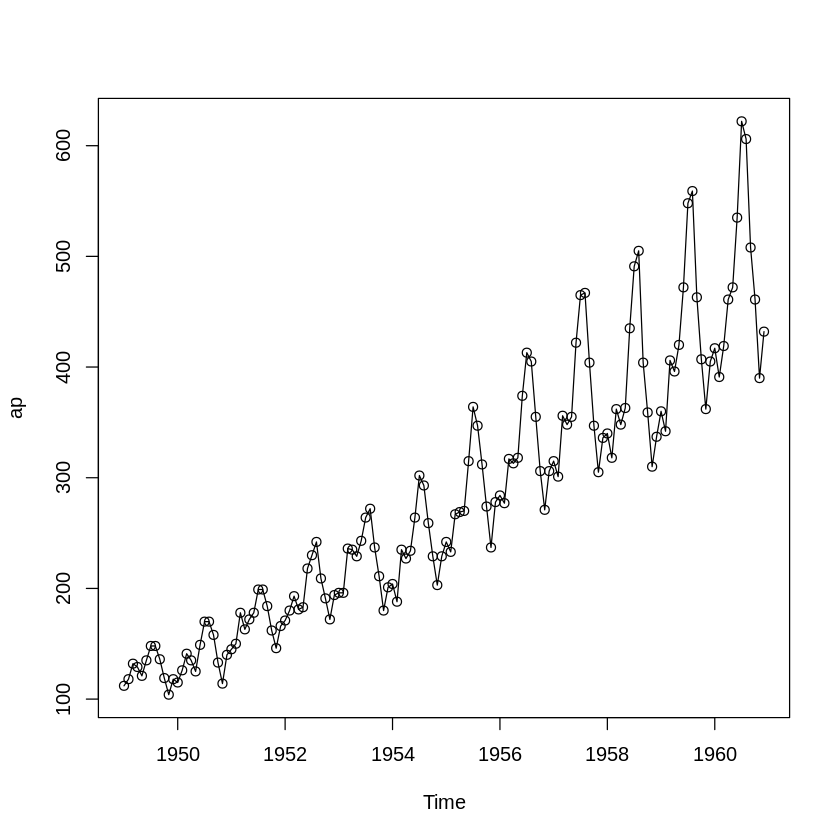

In [3]:
plot(ap, type="o")

Pomocou funkcie `window` je možné vybrať podmnožinu časového radu resp. zmeniť
vzorkovaciu frekvenciu, napr. ak chceme vybrať hodnoty iba za rok 1950 (od januára do
decembra) môžeme zadať:

In [ ]:
window(ap, start=c(1950,1), end=c(1950,12))

In [4]:
window(ap, start=c(1950, 1), end=c(1950, 12))

,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
1950,115,126,141,135,125,149,170,170,158,133,114,140


<br/><br/>

### Použitie funkcií nad dátami

Dáta za jednotlivé roky (hlavné časové jednotky) je možné agregovať pomocou funkcie
`aggregate`, napr. priemerné hodnoty za rok je možné vypočítať ako:

In [ ]:
print(aggregate(ap, FUN=mean))

In [6]:
print(aggregate(ap, FUN=mean))

Time Series:
Start = 1949 
End = 1960 
Frequency = 1 
 [1] 126.6667 139.6667 170.1667 197.0000 225.0000 238.9167 284.0000 328.2500
 [9] 368.4167 381.0000 428.3333 476.1667


Dáta je možné agregovať aj s inou frekvenciou, napr. sumu za pol roka (1/2 hlavnej jednotky)
a za štvrť rok (1/4 hlavnej jednotky) môžete vypočítať ako: 

In [ ]:
aggregate(ap, FUN=sum, nfrequency=2)
aggregate(ap, FUN=sum, nfrequency=4)

In [7]:
print(aggregate(ap, FUN=mean, nfrequency=2))

Time Series:
Start = c(1949, 1) 
End = c(1960, 2) 
Frequency = 2 
 [1] 124.5000 128.8333 131.8333 147.5000 164.3333 176.0000 187.6667 206.3333
 [9] 222.5000 227.5000 225.3333 252.5000 266.0000 302.0000 313.8333 342.6667
[17] 349.5000 387.3333 361.0000 401.0000 399.3333 457.3333 449.1667 503.1667


In [8]:
print(aggregate(ap, FUN=mean, nfrequency=4))

         Qtr1     Qtr2     Qtr3     Qtr4
1949 120.6667 128.3333 144.0000 113.6667
1950 127.3333 136.3333 166.0000 129.0000
1951 157.6667 171.0000 194.0000 158.0000
1952 181.3333 194.0000 227.0000 185.6667
1953 209.3333 235.6667 257.6667 197.3333
1954 209.0000 241.6667 284.6667 220.3333
1955 247.3333 284.6667 341.0000 263.0000
1956 292.6667 335.0000 391.0000 294.3333
1957 324.0000 375.0000 445.3333 329.3333
1958 340.0000 382.0000 466.6667 335.3333
1959 369.3333 429.3333 523.3333 391.3333
1960 409.0000 489.3333 578.6667 427.6667


Všetky hodnoty je možné agregovať priamo, napr. priemer môžeme určiť funkciou mean:

In [10]:
mean(ap)

[1] 280.2986

<br/><br/>
### Možnosti vytvorenia časových radov

1. Objekt časového radu je možné vytvoriť aj z **vektora číselných hodnôt**. Napr. pre priebeh
funkcie `0.25sin(10x) + 0.5x + 1` na intervale 0 az 5 s krokom 0.1:

In [ ]:
x = seq(from=0, to=5, by=0.1)
y = 0.25*sin(10*x) + 0.5*x + 1

Objekt vytvoríme funkciou `ts`, kde nastavíme počiatočný čas a frekvenciu vzorkovania, napr.:

In [ ]:
t = ts(y, start=c(2017,1), frequency=12)
plot(t)

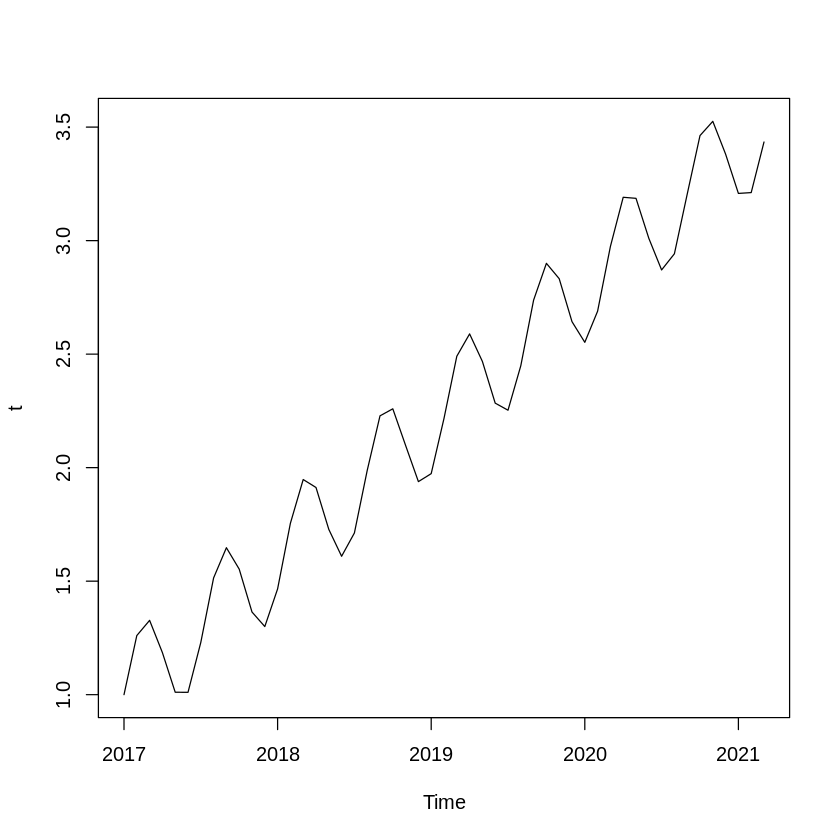

In [11]:
x = seq(from=0, to=5, by=0.1)
y = 0.25*sin(10*x)+0.5*x+1

t = ts(y, start=c(2017, 1), frequency=12)
plot(t)

2. Pomocou funkcie ts môžeme vytvoriť časový rad aj z **tabuľkových dát**. Dáta môžeme stiahnuť
priamo z internetu, napr. nasledujúci súbor Maine.dat udáva mesačnú mieru nezamestnanosti
v štáte Maine za obdobie 1996 do 2006:

In [12]:
data = read.table("data/Maine.dat", header=TRUE) 
data

unemploy
<dbl>
6.7
6.7
6.4
5.9
5.2
4.8
4.8
4.0
4.2


In [ ]:
maine = ts(data, start=c(1996,1), frequency=12)
maine

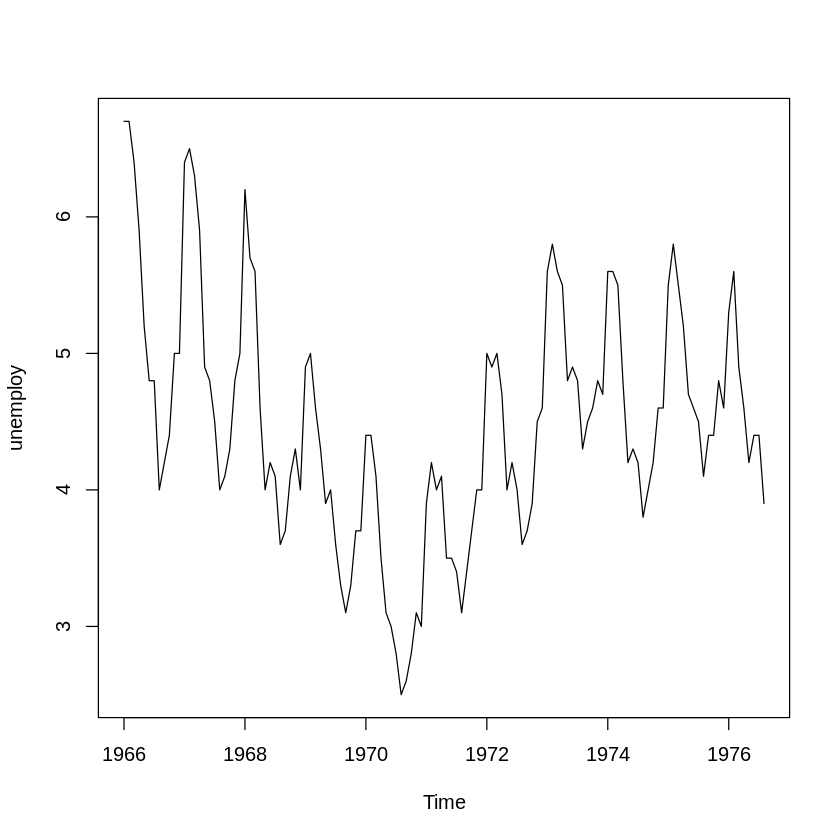

In [14]:
data = read.table("data/Maine.dat", header=TRUE)
t  = ts(data, start = c(1966, 1), frequency = 12)
plot(t)

<br/><br/>
## <span style="color:green"> **Základné charakteristiky časových radov** </span>

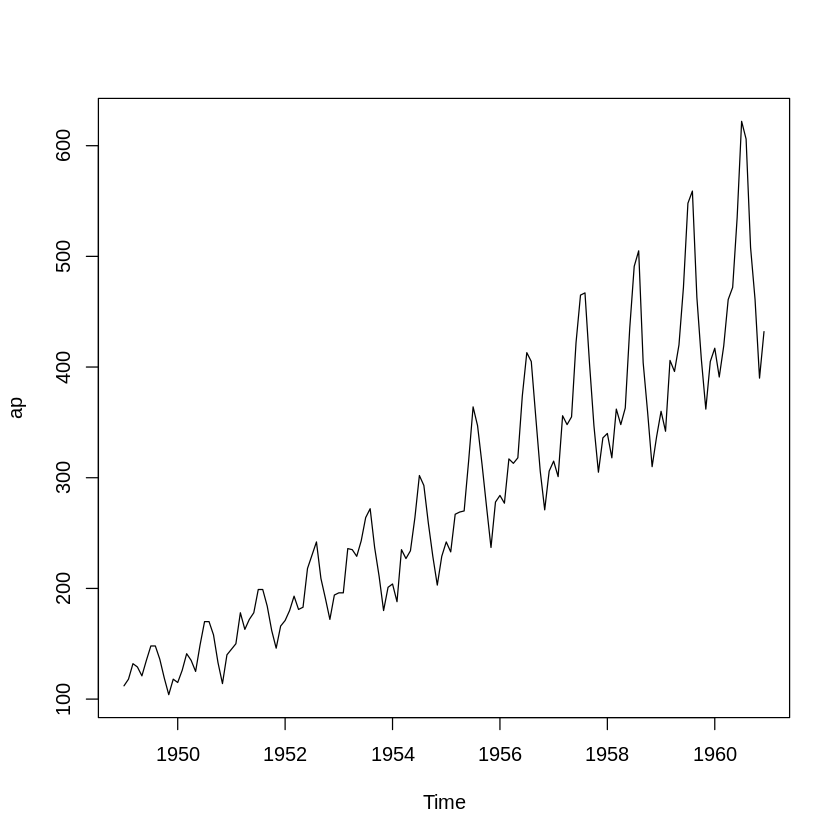

In [15]:
plot(ap)

Z priebehu dát `AirPassengers` vidno, že sa počet pasažierov postupne systematicky zvyšuje,
tzn. dáta majú rastúci **trend**. Okrem trendu vidno cyklické zmeny, ktoré sa periodicky opakujú
– ide o tzv. **sezónnosť**. Časové rady môžeme modelovať rôznou kombináciou trendu `t`,
sezónnosti `s` a **náhodnej zložky** `z`. Najjednoduchším modelom je **aditívny model**, kde sa
hodnoty radu rovnajú súčtu zložiek: `x = t + s + z`. Medzi ďalšie modely patrí napr.
**multiplikatívny model**: `x = t.s.z`.

Najjednoduchší spôsob extrahovania **trendu** je pomocou **centrovaného kĺzavého priemeru**
v okolí každej hodnoty `xt`, ktorý je možné vypočítať pomocou funkcie `filter`. Centrovaný
kĺzavý priemer je vážený priemer, kde prvá a posledná hodnota má váhu 1/2, tzn. napr. pre 12
mesiacov sú váhy `(0.5,1,1,1,1,1,1,1,1,1,1,0.5)/12`:

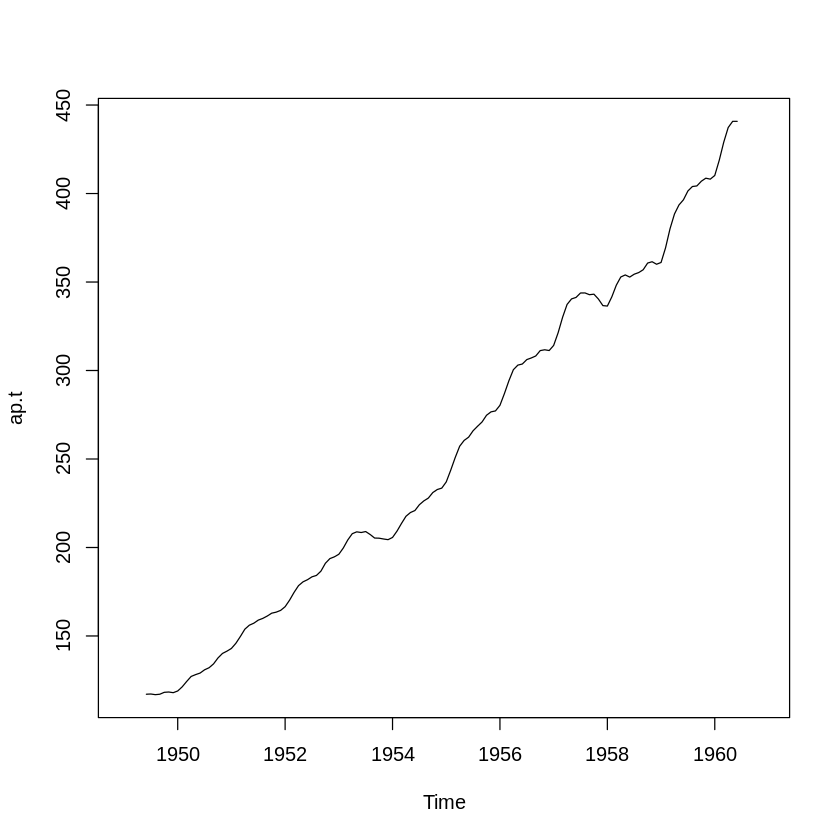

In [16]:
ap.t = filter(ap, c(0.5,1,1,1,1,1,1,1,1,1,1,0.5)/12)
plot(ap.t)

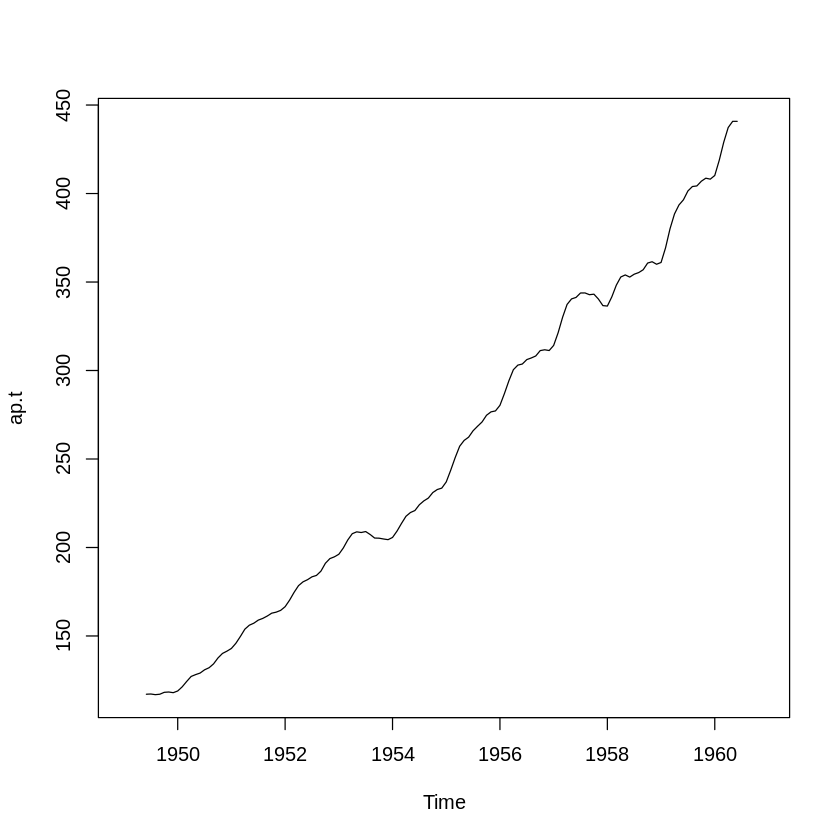

In [19]:
ap.t = filter(ap, c(0.5, 1,1,1,1,1,1,1,1,1,1,0.5)/12)
plot(ap.t)

ap.sz = ap-ap.t

Pre aditívny model je možné zvyšné zložky extrahovať odpočítaním od pôvodného radu:

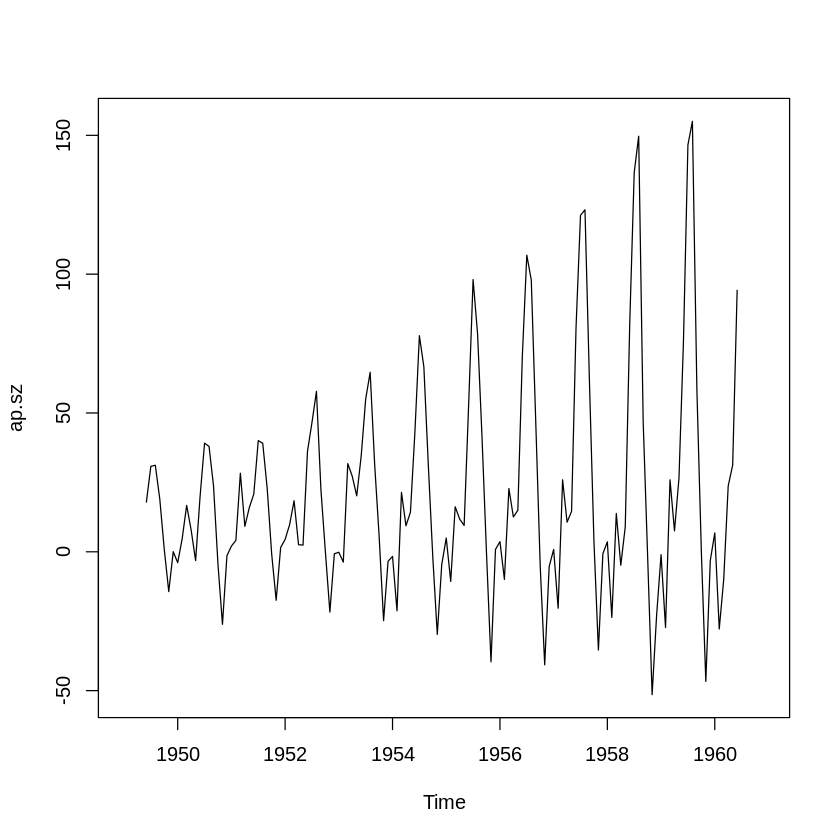

In [20]:
ap.sz = ap - ap.t
plot(ap.sz)

Z priebehu vidno, že sa cyklické zložky postupne zvyšujú, čo môže indikovať, že je pre tieto
dáta vhodnejší multiplikatívny model. Všetky zložky časového radu pre rôzne typy modelov
je možné vypočítať pomocou funkcie `decompose`, napr. pre **multiplikatívny model**:

In [ ]:
ap.decomp = decompose(ap, type="multiplicative")
plot(ap.decomp)

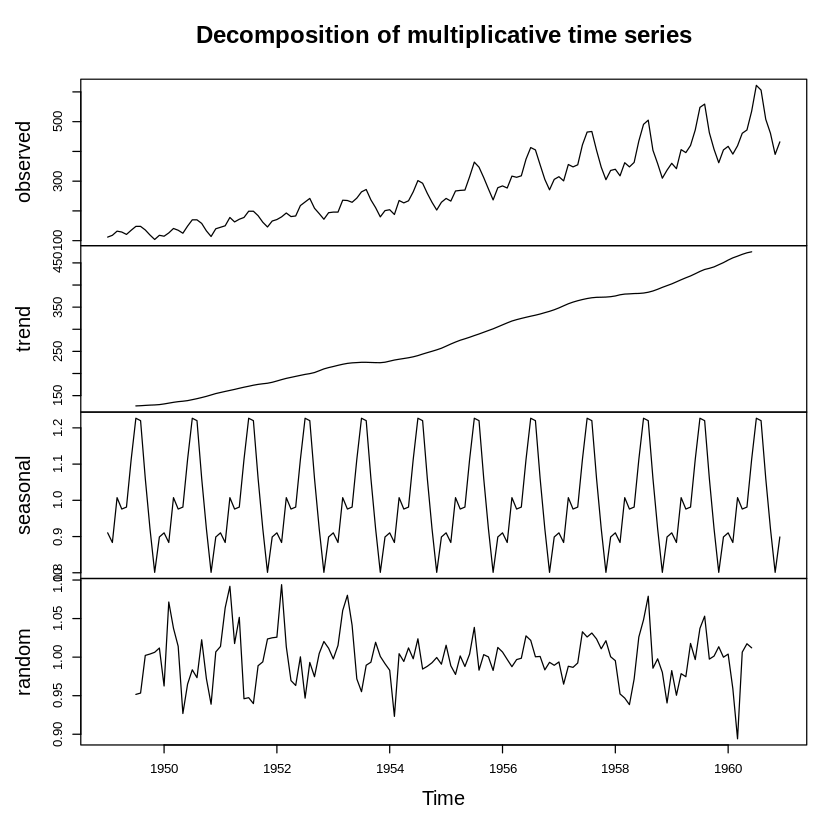

In [25]:
ap.decomp=decompose(ap, type="multiplicative")
plot(ap.decomp)

Jednotlivé zložky modelu sú dostupné vo vlastnostiach `seasonal`, `trend` a `random`. Napr.
nasledujúci príkaz vypočíta základné štatistiky pre **sezónnu zložku**:

In [27]:
summary(ap.decomp$seasonal)
summary(ap.decomp$trend)
summary(ap.decomp$random)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 0.8012  0.9074  0.9786  1.0000  1.0736  1.2266 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max.    NA's 
  126.8   190.7   259.5   278.0   372.2   475.0      12 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max.    NA's 
 0.8941  0.9829  0.9982  0.9982  1.0152  1.0940      12 

<br/><br/>
### Úlohy

**1.** Načítajte dáta `Maine` a vytvorte časový rad pre
mesačné dáta od januára 1996. Vykreslite priebeh. Vypočítajte priemernú hodnotu pre
prvé tri a posledné tri mesiace v roku 1996. Zistite o koľko % sa tieto priemery
odlišujú od priemeru počas celého roku 1996.

In [6]:
?ts

ts {stats},R Documentation
data,a vector or matrix of the observed time-series values. A data frame will be coerced to a numeric matrix via data.matrix. (See also ‘Details’.)
start,"the time of the first observation. Either a single number or a vector of two numbers (the second of which is an integer), which specify a natural time unit and a (1-based) number of samples into the time unit. See the examples for the use of the second form."
end,"the time of the last observation, specified in the same way as start."
frequency,the number of observations per unit of time.
deltat,"the fraction of the sampling period between successive observations; e.g., 1/12 for monthly data. Only one of frequency or deltat should be provided."
ts.eps,time series comparison tolerance. Frequencies are considered equal if their absolute difference is less than ts.eps.
class,"class to be given to the result, or none if NULL or ""none"". The default is ""ts"" for a single series, c(""mts"", ""ts"", ""matrix"") for multiple series."
names,"a character vector of names for the series in a multiple series: defaults to the colnames of data, or Series 1, Series 2, ...."
x,an arbitrary R object.
...,arguments passed to methods (unused for the default method).


In [5]:
data = read.table("data/Maine.dat", header=TRUE)
cr = ts(data, start=c(1996, 1), frequency=12)
cr1 = ts(data, start=c(1996, 1))

cr

,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
1996,6.7,6.7,6.4,5.9,5.2,4.8,4.8,4.0,4.2,4.4,5.0,5.0
1997,6.4,6.5,6.3,5.9,4.9,4.8,4.5,4.0,4.1,4.3,4.8,5.0
1998,6.2,5.7,5.6,4.6,4.0,4.2,4.1,3.6,3.7,4.1,4.3,4.0
1999,4.9,5.0,4.6,4.3,3.9,4.0,3.6,3.3,3.1,3.3,3.7,3.7
2000,4.4,4.4,4.1,3.5,3.1,3.0,2.8,2.5,2.6,2.8,3.1,3.0
2001,3.9,4.2,4.0,4.1,3.5,3.5,3.4,3.1,3.4,3.7,4.0,4.0
2002,5.0,4.9,5.0,4.7,4.0,4.2,4.0,3.6,3.7,3.9,4.5,4.6
2003,5.6,5.8,5.6,5.5,4.8,4.9,4.8,4.3,4.5,4.6,4.8,4.7
2004,5.6,5.6,5.5,4.8,4.2,4.3,4.2,3.8,4.0,4.2,4.6,4.6
2005,5.5,5.8,5.5,5.2,4.7,4.6,4.5,4.1,4.4,4.4,4.8,4.6


In [7]:
#plot(cr)
s3 = window(cr1, start=c(1996, 1), end=c(1996, 3))
e3 = window(cr1, start=c(1996, 10), end=c(1996, 12))

print(aggregate(s3, FUN=mean))
print(aggregate(e3, FUN=mean))

Time Series:
Start = 1996 
End = 1998 
Frequency = 1 
     unemploy
[1,]      6.7
[2,]      6.7
[3,]      6.4
Time Series:
Start = 2005 
End = 2007 
Frequency = 1 
     unemploy
[1,]      4.4
[2,]      5.0
[3,]      5.0


**2.** Pre dátovú množinu `Maine` vypočítajte agregovaný časový rad pre priemerné
štvrťročné hodnoty a zobrazte jeho priebeh.

In [8]:
?aggregate

aggregate {stats},R Documentation
x,"an R object. For the formula method a formula, such as y ~ x or cbind(y1, y2) ~ x1 + x2, where the y variables are numeric data to be split into groups according to the grouping x variables (usually factors)."
by,"a list of grouping elements, each as long as the variables in the data frame x. The elements are coerced to factors before use."
FUN,a function to compute the summary statistics which can be applied to all data subsets.
simplify,a logical indicating whether results should be simplified to a vector or matrix if possible.
drop,a logical indicating whether to drop unused combinations of grouping values. The non-default case drop=FALSE has been amended for R 3.5.0 to drop unused combinations.
data,a data frame (or list) from which the variables in formula should be taken.
subset,an optional vector specifying a subset of observations to be used.
na.action,a function which indicates what should happen when the data contain NA values. The default is to ignore missing values in the given variables.
nfrequency,new number of observations per unit of time; must be a divisor of the frequency of x.
ndeltat,new fraction of the sampling period between successive observations; must be a divisor of the sampling interval of x.


In [50]:
print(aggregate(cr, FUN=mean, nfrequency=4))

         Qtr1     Qtr2     Qtr3     Qtr4
1996 6.600000 5.300000 4.333333 4.800000
1997 6.400000 5.200000 4.200000 4.700000
1998 5.833333 4.266667 3.800000 4.133333
1999 4.833333 4.066667 3.333333 3.566667
2000 4.300000 3.200000 2.633333 2.966667
2001 4.033333 3.700000 3.300000 3.900000
2002 4.966667 4.300000 3.766667 4.333333
2003 5.666667 5.066667 4.533333 4.700000
2004 5.566667 4.433333 4.000000 4.466667
2005 5.600000 4.833333 4.333333 4.600000
2006 5.266667 4.400000                  


**3.** Načítajte dáta `cbe`. Dáta obsahujú dátovú
množinu so stĺpcami určujúcimi mesačnú produkciu čokolády (stĺpec 1), piva (stĺpec 2)
a elektrickej energie (stĺpec 3) od roku 1958. Načítajte dáta ako časové rady (pre výber
stĺpca môžete použiť zápis CBE[,1], CBE[,2], CBE[,3). Zobrazte všetky tri časové
rady v jednom grafe pomocou funkcie `plot` a `cbind`.

In [58]:
?cbind

cbind {base},R Documentation
...,"(generalized) vectors or matrices. These can be given as named arguments. Other R objects may be coerced as appropriate, or S4 methods may be used: see sections ‘Details’ and ‘Value’. (For the ""data.frame"" method of cbind these can be further arguments to data.frame such as stringsAsFactors.)"
deparse.level,"integer controlling the construction of labels in the case of non-matrix-like arguments (for the default method): deparse.level = 0 constructs no labels; the default, deparse.level = 1 or 2 constructs labels from the argument names, see the ‘Value’ section below."
make.row.names,(only for data frame method:) logical indicating if unique and valid row.names should be constructed from the arguments.
stringsAsFactors,"logical, passed to as.data.frame; only has an effect when the ... arguments contain a (non-data.frame) character."
factor.exclude,"if the data frames contain factors, the default TRUE ensures that NA levels of factors are kept, see PR#17562 and the ‘Data frame methods’. In R versions up to 3.6.x, factor.exclude = NA has been implicitly hardcoded (R <= 3.6.0) or the default (R = 3.6.x, x >= 1)."


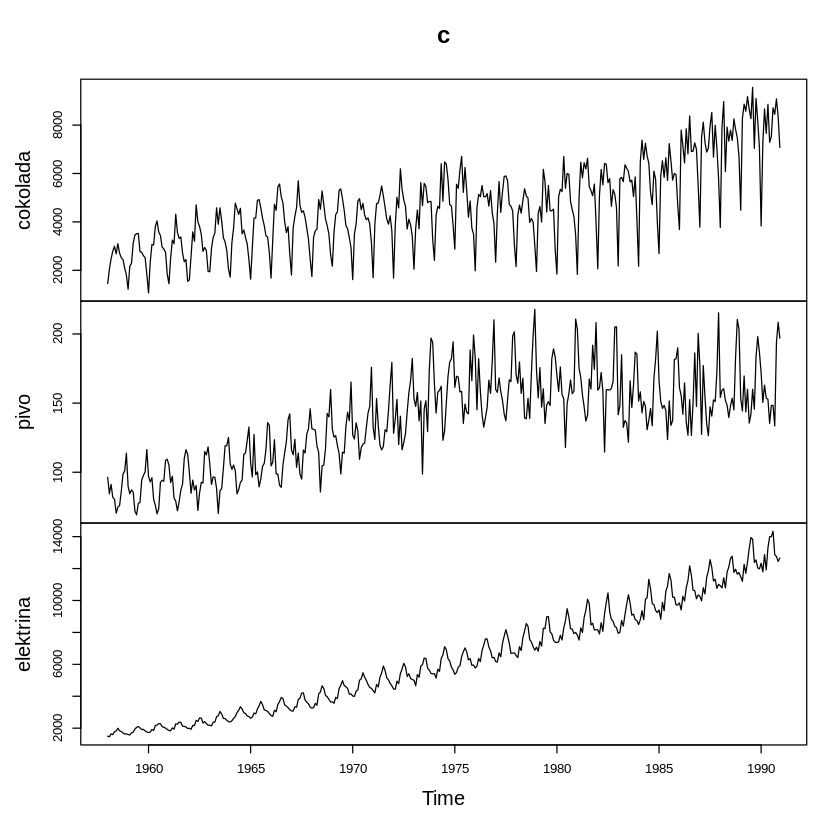

In [60]:
d = read.table("data/cbe.dat", header=TRUE)
cokolada = ts(d[,1], start=c(1958,1), frequency=12)
pivo = ts(d[,2], start=c(1958,1), frequency=12)
elektrina = ts(d[,3], start=c(1958,1), frequency=12)


c = cbind(cokolada, pivo, elektrina)
plot(c)

In [ ]:
data = read.table("data/cbe.dat", header=TRUE)
cok = ts(data[,1], start=c(1958, 1), frequency=12)

cbind(cok, ...) -> plot

**4.** Vypočítajte koreláciu medzi produkciou čokolády a piva.

In [61]:
cor(cokolada, pivo)

[1] 0.3774314

**5.** Na dátovej množine `AirPassengers` postupne aplikujte kĺzavý priemer s šírkou 4
mesiace, 6 mesiacov a 12 mesiacov (tzn. váhy pre 4 mesiace budú `(0.5,1,1,0.5)/4`).
Vyextrahujte trendovú zložku pre každý filter podľa aditívneho modelu a zobrazte jej
priebeh.

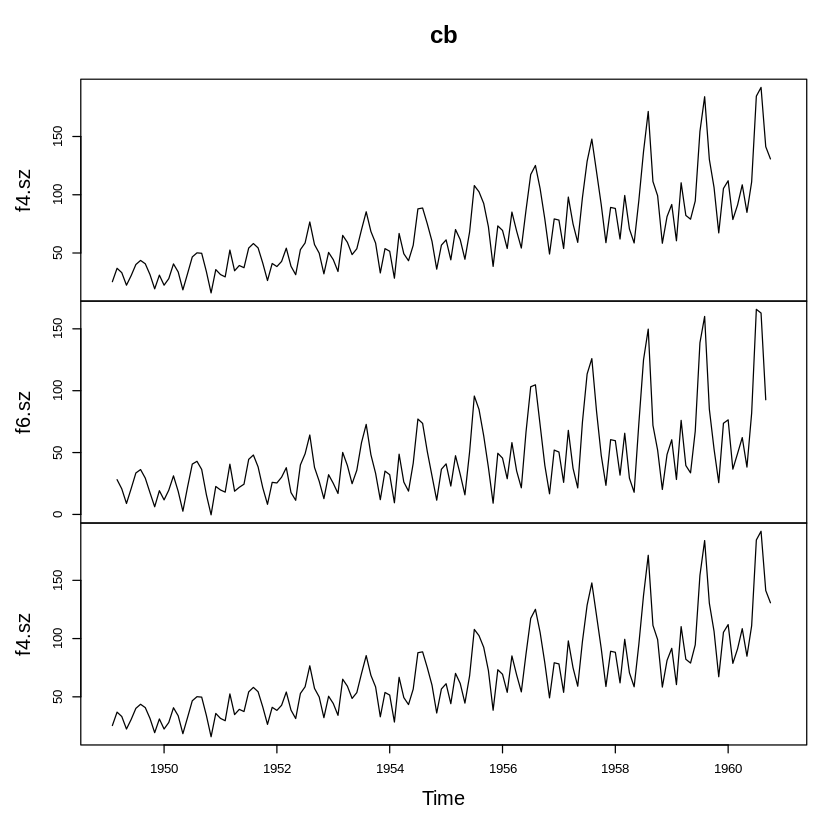

In [66]:
f4 = filter(ap, c(0.5, 1, 1, 0.5)/4)
f6 = filter(ap, c(0.5, 1,1,1,1,0.5)/6)
f12 = filter(ap, c(0.5, 1,1,1,1,1,1,1,1,1,1,1, 0.5)/12)

f4.sz = ap-f4
f6.sz = ap-f6
f12.sz = ap-f12


cb = cbind(f4.sz, f6.sz, f4.sz)
plot(cb)

**6.** Pomocou funkcie decompose vygenerujte a zobrazte zložky pre aditívny
a multiplikatívny model pre dátovú množinu `AirPassangers`

In [9]:
?decompose

decompose {stats},R Documentation
x,A time series.
type,The type of seasonal component. Can be abbreviated.
filter,"A vector of filter coefficients in reverse time order (as for AR or MA coefficients), used for filtering out the seasonal component. If NULL, a moving average with symmetric window is performed."
x,The original series.
seasonal,"The seasonal component (i.e., the repeated seasonal figure)."
figure,The estimated seasonal figure only.
trend,The trend component.
random,The remainder part.
type,The value of type.


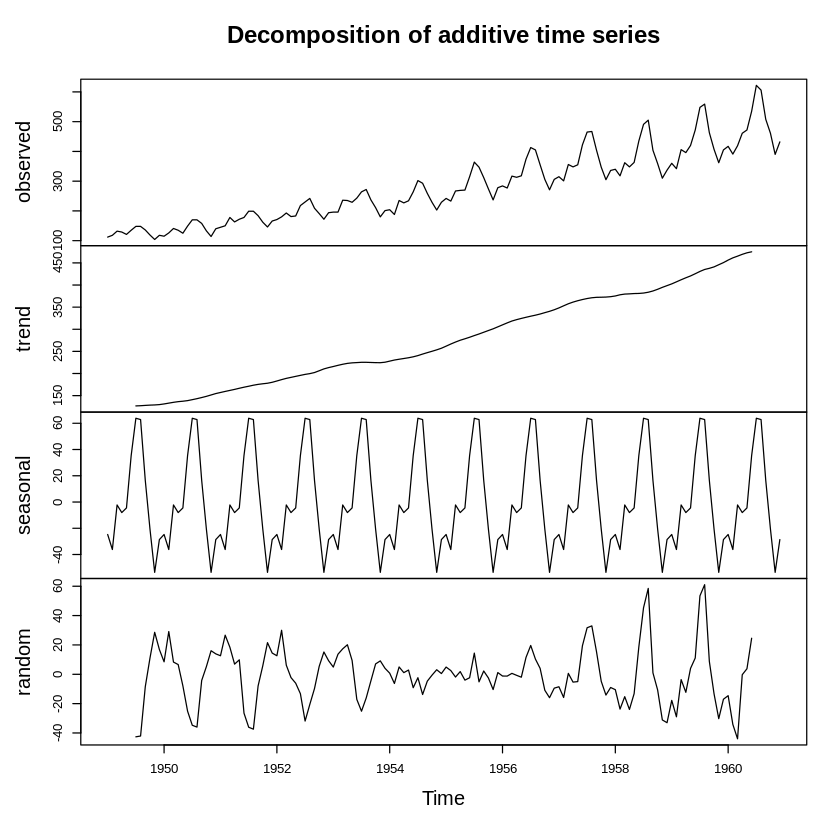

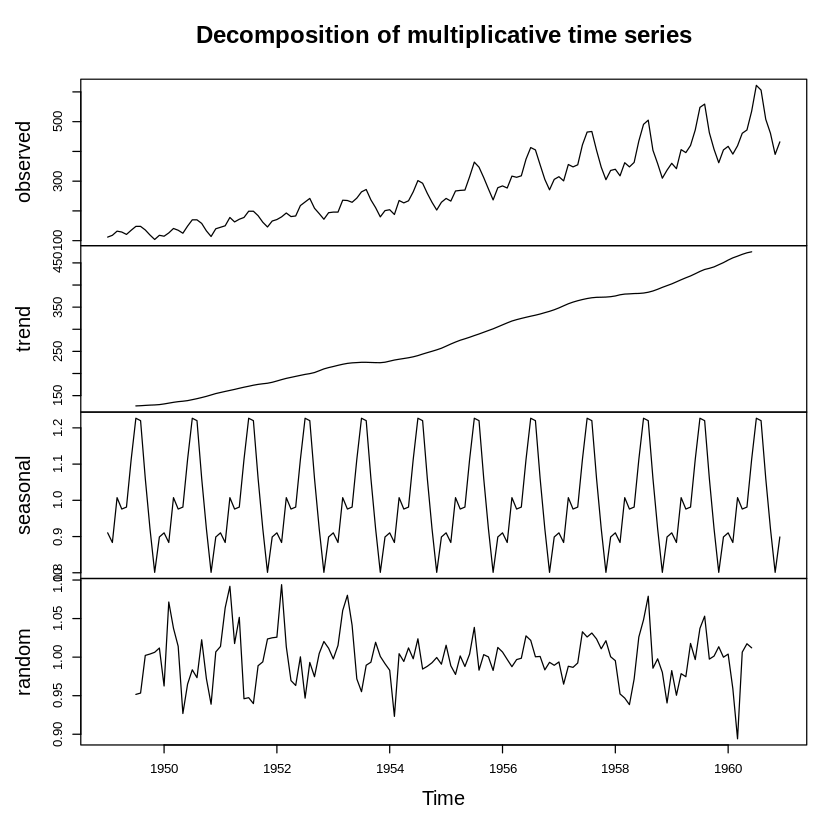

In [71]:
ad = decompose(ap, type="additive")
mu = decompose(ap, type="multiplicative")

plot(ad)
plot(mu)

In [67]:
?decompose

decompose {stats},R Documentation
x,A time series.
type,The type of seasonal component. Can be abbreviated.
filter,"A vector of filter coefficients in reverse time order (as for AR or MA coefficients), used for filtering out the seasonal component. If NULL, a moving average with symmetric window is performed."
x,The original series.
seasonal,"The seasonal component (i.e., the repeated seasonal figure)."
figure,The estimated seasonal figure only.
trend,The trend component.
random,The remainder part.
type,The value of type.


**7.** Na intervale [0,5] s krokom 0.1 vygenerujte priebeh funkcií `y = 0.5x + 1 a z = 0.25sin(10x)`. Vygenerujte rovnako veľký náhodný vektor `n` podľa normálneho
rozdelenia s 0 strednou hodnotou a štandardnou odchýlkou 0.5. Vykreslite priebehy
funkcií na jednom zloženom grafe pomocou funkcie `plot` a `cbind`.

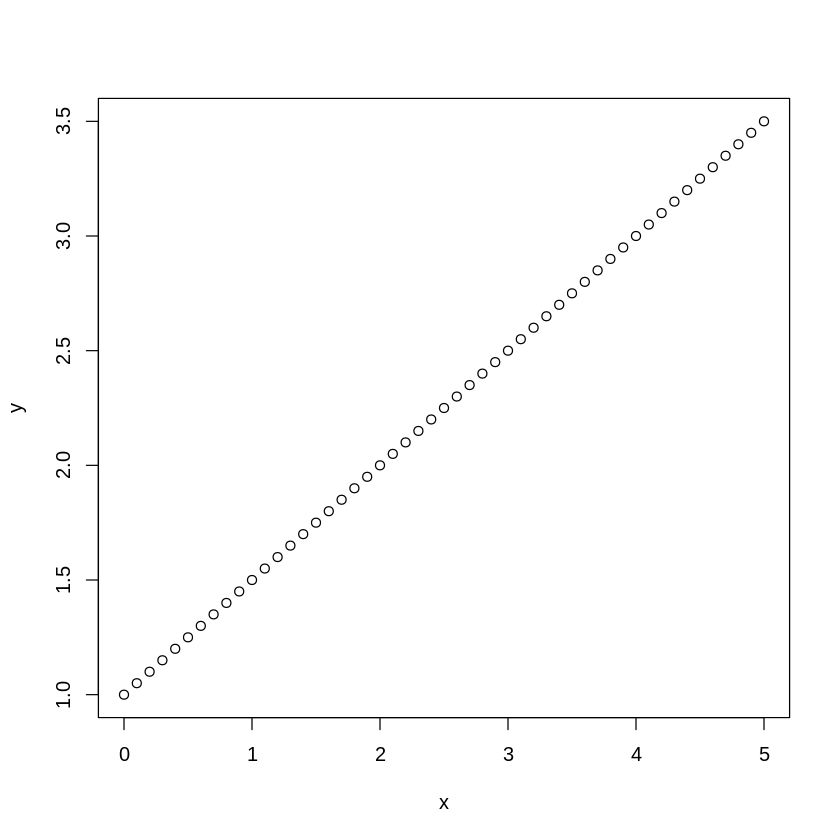

In [72]:
x = seq(from=0, to=5, by=0.1)
y = 0.5*x+1
z = 0.25*sin(10*x)

n = rnorm(length(x), mean=0, sd=0.5)

cb = cbind(x, y, z, n)
plot(cb)

**8.** Zo zložiek s predchádzajúceho príkladu vytvorte časový rad s aditívnym modelom `y + z + n`, a multiplikatívnym modelom `y.z.n`.

In [76]:
ad = y+z+n
mu = y*z*n 

tsad = ts(ad, start=c(2017, 1), frequency=12)
tsmu = ts(mu, start=c(2017, 1), frequency=12)



**9.** Dekomponujte časové rady z predchádzajúceho priebehu pomocou funkcie
`decompose`. Vytvorte pre oba priebehy obe dekompozície aj pre aditívny aj
multiplikatívny model.

In [80]:
tsad.ad = decompose(tsad, "additive")
tsad.mu = decompose(tsad, "multiplicative")

tsmu.ad = decompose(tsmu, "additive")
tsmu.mu = decompose(tsmu, "multiplicative")


**10.** Nahraďte lineárny trend logaritmickým `y = log(x + 1)`, vytvorte aditívny
a multiplikatívny časový rad a dekomponujte ich zložky